In [1]:
# ============================================================
# CELL 1 - Load Cleaned Data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/processed/cleaned_data.csv"
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

FEATURE ENGINEERING
Dataset shape: (1817, 23)

Columns:
['country', 'year', 'iso_code_co2', 'population_co2', 'gdp_co2', 'co2', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'primary_energy_consumption_energy', 'fossil_fuel_consumption', 'fossil_share_energy', 'renewables_consumption', 'renewables_share_energy', 'renewables_electricity', 'renewables_share_elec', 'solar_consumption', 'solar_share_energy', 'wind_consumption', 'wind_share_energy', 'hydro_consumption', 'hydro_share_energy']


In [2]:
# ============================================================
# CELL 2 - Select Modelling Features
# ============================================================

target = "co2"

features = [
    "year", "population_co2", "gdp_co2", "primary_energy_consumption_energy",
    "fossil_share_energy", "renewables_share_energy", "renewables_electricity",
    "renewables_share_elec", "solar_share_energy", "wind_share_energy",
    "hydro_share_energy"
]

model_df = df[["country", "iso_code_co2", "year", target] + features[1:]].copy()

print("=" * 60)
print("SELECTED FEATURES")
print("=" * 60)
print("Target:", target)
print("Number of features:", len(features))
print("\nFeatures:")
for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

SELECTED FEATURES
Target: co2
Number of features: 11

Features:
1. year
2. population_co2
3. gdp_co2
4. primary_energy_consumption_energy
5. fossil_share_energy
6. renewables_share_energy
7. renewables_electricity
8. renewables_share_elec
9. solar_share_energy
10. wind_share_energy
11. hydro_share_energy


In [3]:
# ============================================================
# CELL 3 - Create Derived Features
# ============================================================

model_df["gdp_per_capita"] = model_df["gdp_co2"] / model_df["population_co2"]
model_df["energy_per_capita"] = (model_df["primary_energy_consumption_energy"] * 1e9) / model_df["population_co2"]

derived_features = ["gdp_per_capita", "energy_per_capita"]

print("=" * 60)
print("DERIVED FEATURES")
print("=" * 60)
print("Created features:")
for feature in derived_features:
    print(f"{feature}: derived from existing economic, population and energy variables")

display(model_df[["country", "year"] + derived_features].head())

DERIVED FEATURES
Created features:
gdp_per_capita: derived from existing economic, population and energy variables
energy_per_capita: derived from existing economic, population and energy variables


,country,year,gdp_per_capita,energy_per_capita
0,Algeria,2000,6748.474822,9705.755792
1,Algeria,2001,7130.914508,9920.229670
2,Algeria,2002,7727.700607,10139.907530
3,Algeria,2003,8502.306958,10471.285345
4,Algeria,2004,9095.591770,10720.078937


FEATURE STATISTICS & CORRELATIONS
Feature statistics:


,count,mean,std,min,25%,50%,75%,max
population_co2,1817.0,7.378757e+07,2.077922e+08,2.812930e+05,5.529616e+06,1.960036e+07,5.928810e+07,1.426437e+09
gdp_co2,1817.0,1.134676e+12,2.661526e+12,9.307402e+09,1.692262e+11,3.605170e+11,9.620958e+11,2.696602e+13
primary_energy_consumption_energy,1817.0,1.736402e+03,4.575363e+03,2.770799e+01,2.305396e+02,4.906227e+02,1.362193e+03,4.451649e+04
fossil_share_energy,1817.0,8.419012e+01,1.658273e+01,1.387364e+01,7.720554e+01,8.814314e+01,9.703559e+01,1.000000e+02
renewables_share_energy,1817.0,1.165717e+01,1.448739e+01,0.000000e+00,1.890443e+00,6.311814e+00,1.695980e+01,8.612636e+01
renewables_electricity,1817.0,5.723182e+01,1.710681e+02,0.000000e+00,2.120000e+00,1.176000e+01,3.800000e+01,2.670660e+03
renewables_share_elec,1817.0,2.533582e+01,2.608831e+01,0.000000e+00,4.986488e+00,1.584220e+01,3.935743e+01,1.000000e+02
solar_share_energy,1817.0,3.532386e-01,8.193346e-01,0.000000e+00,0.000000e+00,4.933649e-03,2.031464e-01,7.773575e+00
wind_share_energy,1817.0,1.107288e+00,2.467720e+00,0.000000e+00,4.689944e-04,7.400563e-02,1.008326e+00,2.452765e+01
hydro_share_energy,1817.0,8.277497e+00,1.221328e+01,0.000000e+00,3.749971e-01,3.179570e+00,1.106428e+01,7.063149e+01



Correlation with CO₂:


,correlation
co2,1.000000
primary_energy_consumption_energy,0.987365
gdp_co2,0.946075
renewables_electricity,0.848423
population_co2,0.752524
fossil_share_energy,0.063204
solar_share_energy,0.049452
wind_share_energy,0.004334
energy_per_capita,-0.004807
gdp_per_capita,-0.015562


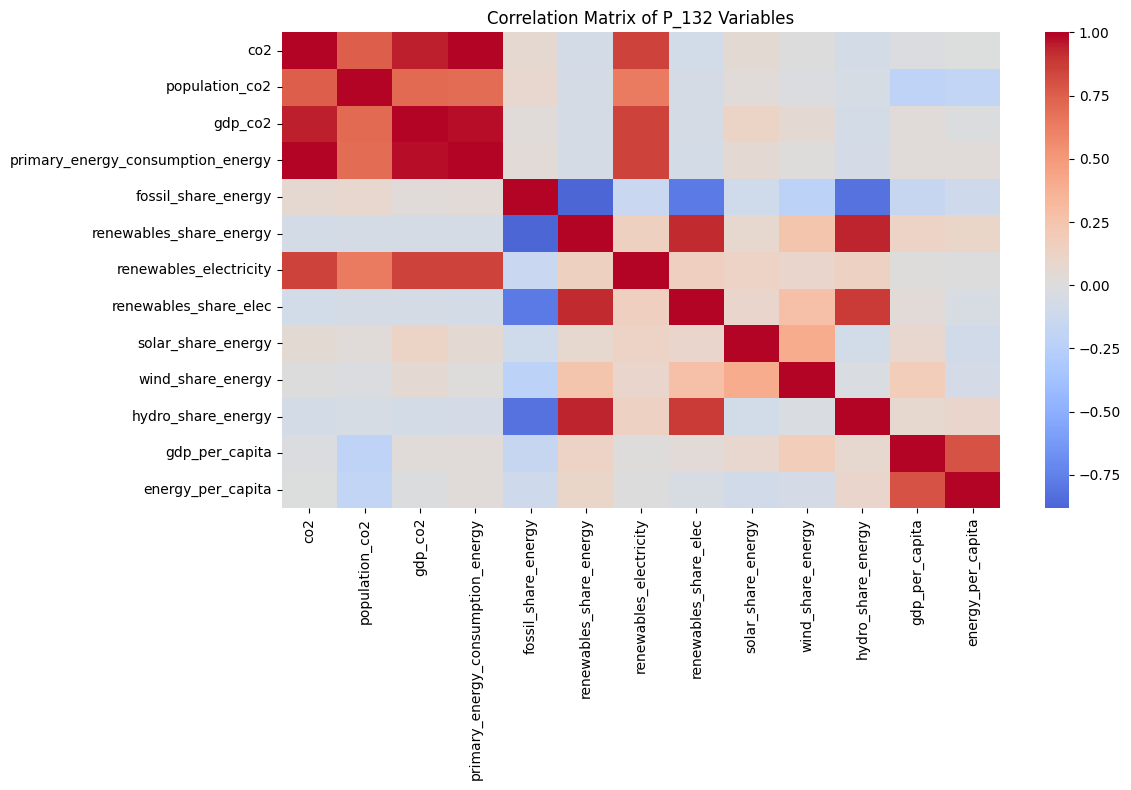

In [4]:
# ============================================================
# CELL 4 - Feature Statistics & Correlations
# ============================================================

numeric_features = features[1:] + derived_features

print("=" * 60)
print("FEATURE STATISTICS & CORRELATIONS")
print("=" * 60)

print("Feature statistics:")
display(model_df[numeric_features].describe().T)

correlation = model_df[["co2"] + numeric_features].corr()

print("\nCorrelation with CO₂:")
display(correlation["co2"].sort_values(ascending=False).to_frame("correlation"))

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of P_132 Variables")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CELL 5 - Final Modeling Dataset
# ============================================================

final_features = [
    "year", "population_co2", "gdp_co2", "primary_energy_consumption_energy",
    "fossil_share_energy", "renewables_share_energy", "renewables_electricity",
    "renewables_share_elec", "solar_share_energy", "wind_share_energy",
    "hydro_share_energy", "gdp_per_capita", "energy_per_capita"
]

model_df = model_df[["country", "iso_code_co2", "co2"] + final_features].dropna().copy()

OUTPUT_PATH = "../data/processed/modeling_data.csv"
model_df.to_csv(OUTPUT_PATH, index=False)

print("=" * 60)
print("FINAL MODELING DATASET")
print("=" * 60)
print("Rows:", len(model_df))
print("Columns:", model_df.shape[1])
print("Features:", len(final_features))
print("Missing values:", model_df.isna().sum().sum())
print("Saved to:", OUTPUT_PATH)

display(model_df.head())

FINAL MODELING DATASET
Rows: 1817
Columns: 16
Features: 13
Missing values: 0
Saved to: ../data/processed/modeling_data.csv


,country,iso_code_co2,co2,year,population_co2,gdp_co2,primary_energy_consumption_energy,fossil_share_energy,renewables_share_energy,renewables_electricity,renewables_share_elec,solar_share_energy,wind_share_energy,hydro_share_energy,gdp_per_capita,energy_per_capita
0,Algeria,DZA,84.552452,2000,30903894.0,2.085542e+11,299.945648,99.949989,0.050011,0.05,0.196850,0.0,0.0,0.050011,6748.474822,9705.755792
1,Algeria,DZA,86.019196,2001,31331226.0,2.234203e+11,310.812958,99.938675,0.061328,0.07,0.262960,0.0,0.0,0.061328,7130.914508,9920.229670
2,Algeria,DZA,89.658401,2002,31750832.0,2.453609e+11,321.950500,99.951492,0.048507,0.06,0.216998,0.0,0.0,0.048507,7727.700607,10139.907530
3,Algeria,DZA,94.077927,2003,32175813.0,2.735686e+11,336.922119,99.785660,0.214343,0.26,0.879269,0.0,0.0,0.214343,8502.306958,10471.285345
4,Algeria,DZA,90.852531,2004,32628286.0,2.967736e+11,349.777802,99.805504,0.194495,0.25,0.800000,0.0,0.0,0.194495,9095.591770,10720.078937
